In [1]:
%pip install bm3d
%pip install colour-demosaicing
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from bm3d import bm3d_rgb
from skimage import data, img_as_float
from skimage.io import imread
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from skimage.restoration import denoise_tv_chambolle

try:
    from colour_demosaicing import demosaicing_CFA_Bayer_Menon2007, demosaicing_CFA_Bayer_bilinear
    have_demosaic = True
except ImportError:
    have_demosaic = False


## CFA Forward and Adjoint

In [4]:

def A(x):
    """Map an RGB image to a CFA image (BGGR pattern)."""
    y = np.zeros(x.shape[0:2])
    y[1::2, 1::2] = x[1::2, 1::2, 0]  # R
    y[0::2, 1::2] = x[0::2, 1::2, 1]  # G
    y[1::2, 0::2] = x[1::2, 0::2, 1]  # G
    y[0::2, 0::2] = x[0::2, 0::2, 2]  # B
    return y

def AT(x):
    """Back-project CFA to RGB with zeros where unknown."""
    y = np.zeros(x.shape + (3,))
    y[1::2, 1::2, 0] = x[1::2, 1::2]  # R
    y[0::2, 1::2, 1] = x[0::2, 1::2]  # G
    y[1::2, 0::2, 1] = x[1::2, 0::2]  # G
    y[0::2, 0::2, 2] = x[0::2, 0::2]  # B
    return y

## Demosaicing Wrapper

In [5]:
if have_demosaic:
    def demosaic(cfaimg):
        return demosaicing_CFA_Bayer_Menon2007(cfaimg, pattern='BGGR')
else:
    def demosaic(cfaimg):
        return demosaicing_CFA_Bayer_bilinear(cfaimg, pattern='BGGR')

## Plug-and-Play PPP Solver

In [6]:

class PPP:
    class Options(dict):
        def __init__(self, opts=None):
            super().__init__({
                'Verbose': True,
                'RelStopTol': 1e-3,
                'MaxMainIter': 30,
                'L': 0.5,
                'X0': None
            })
            if opts is not None:
                self.update(opts)

    def __init__(self, img_shape, f, gradf, proxg, opt=None):
        self.shape = img_shape
        self.f = f
        self.gradf = gradf
        self.proxg = proxg
        self.opt = PPP.Options(opt)
        self.X = self.opt['X0']
        self.itstat = []
        self.solve_time = 0.0

    def solve(self):
        import time
        t0 = time.time()

        X = self.X.copy()
        L = self.opt['L']
        max_iter = self.opt['MaxMainIter']
        tol = self.opt['RelStopTol']
        verbose = self.opt['Verbose']

        for it in range(max_iter):
            Xprev = X.copy()
            # Gradient step
            G = X - (1.0 / L) * self.gradf(X)
            # Prox step (BM3D)
            X = self.proxg(G, L)
            relchg = np.linalg.norm((X - Xprev).ravel()) / np.linalg.norm(Xprev.ravel())

            self.itstat.append((it+1, self.f(X), relchg))
            if verbose:
                print(f"Iter {it+1:02d}: f(X)={self.f(X):.4f}, relchg={relchg:.3e}")
            if relchg < tol:
                break

        self.solve_time = time.time() - t0
        return X

## Main Experiment

Iter 01: f(X)=2222.0192, relchg=1.591e-01
Iter 02: f(X)=2497.5278, relchg=2.072e-02
Iter 03: f(X)=2516.0053, relchg=5.314e-03
Iter 04: f(X)=2520.0508, relchg=2.553e-03
Iter 05: f(X)=2521.3796, relchg=1.575e-03
Iter 06: f(X)=2521.8911, relchg=1.168e-03
Iter 07: f(X)=2522.1460, relchg=9.819e-04


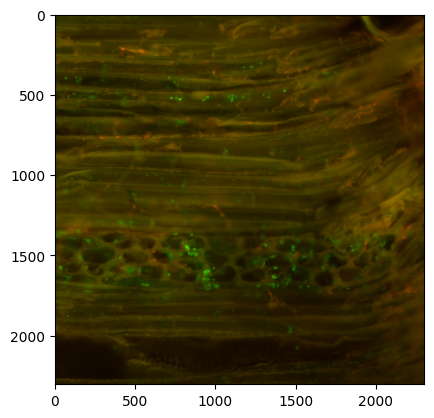

In [7]:
img = imread("Data/1.png") / 255.0  # use 512x512 crop
plt.imshow(img)
np.random.seed(12345)
s = A(img)
nsigma = 3e-2
sn = s + nsigma * np.random.randn(*s.shape)

# Fidelity terms
def f(x):
    return 0.5 * np.linalg.norm((A(x) - sn).ravel())**2

def gradf(x):
    return AT(A(x) - sn)

# BM3D prox
bsigma = 4.5e-2
def proxg(x, L):
    return bm3d_rgb(x, bsigma)

# Baseline BM3D on simple demosaicing
imgb = demosaic(sn)

# Run PPP solver
opt = PPP.Options({'Verbose': True, 'RelStopTol': 1e-3,
                   'MaxMainIter': 30, 'L': 0.5, 'X0': imgb})
b = PPP(img.shape, f, gradf, proxg, opt=opt)
imgp = b.solve()

# TV baseline
demosaiced_sn = demosaic(sn)
img_tv = denoise_tv_chambolle(demosaiced_sn, weight=0.1, channel_axis=2)
img_tv = np.clip(img_tv, 0, 1)

## Metrics

In [10]:
psnr_imgb = psnr(img, imgb)
ssim_imgb = ssim(img, imgb, channel_axis=2, data_range=1)
psnr_imgp = psnr(img, imgp)
ssim_imgp = ssim(img, imgp, channel_axis=2, data_range=1)
psnr_tv = psnr(img, img_tv)
ssim_tv = ssim(img, img_tv, channel_axis=2, data_range=1)

print("\nResults:")
print("PPP PGM solve time:         %5.2f s" % b.solve_time)
print("Baseline demosaicing PSNR:  %5.2f dB" % psnr_imgb)
print("Baseline demosaicing SSIM:  %5.4f"    % ssim_imgb)
print("PPP demosaicing PSNR:       %5.2f dB" % psnr_imgp)
print("PPP demosaicing SSIM:       %5.4f"    % ssim_imgp)
print("TV Demosaicing PSNR:        %5.2f dB" % psnr_tv)
print("TV Demosaicing SSIM:        %5.4f"     % ssim_tv)


Results:
PPP PGM solve time:         1045.47 s
Baseline demosaicing PSNR:  29.78 dB
Baseline demosaicing SSIM:  0.4715
PPP demosaicing PSNR:       37.86 dB
PPP demosaicing SSIM:       0.8634
TV Demosaicing PSNR:        37.63 dB
TV Demosaicing SSIM:        0.8720


## Visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.164412631573..1.00684753826].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0548559699392..0.976459866841].


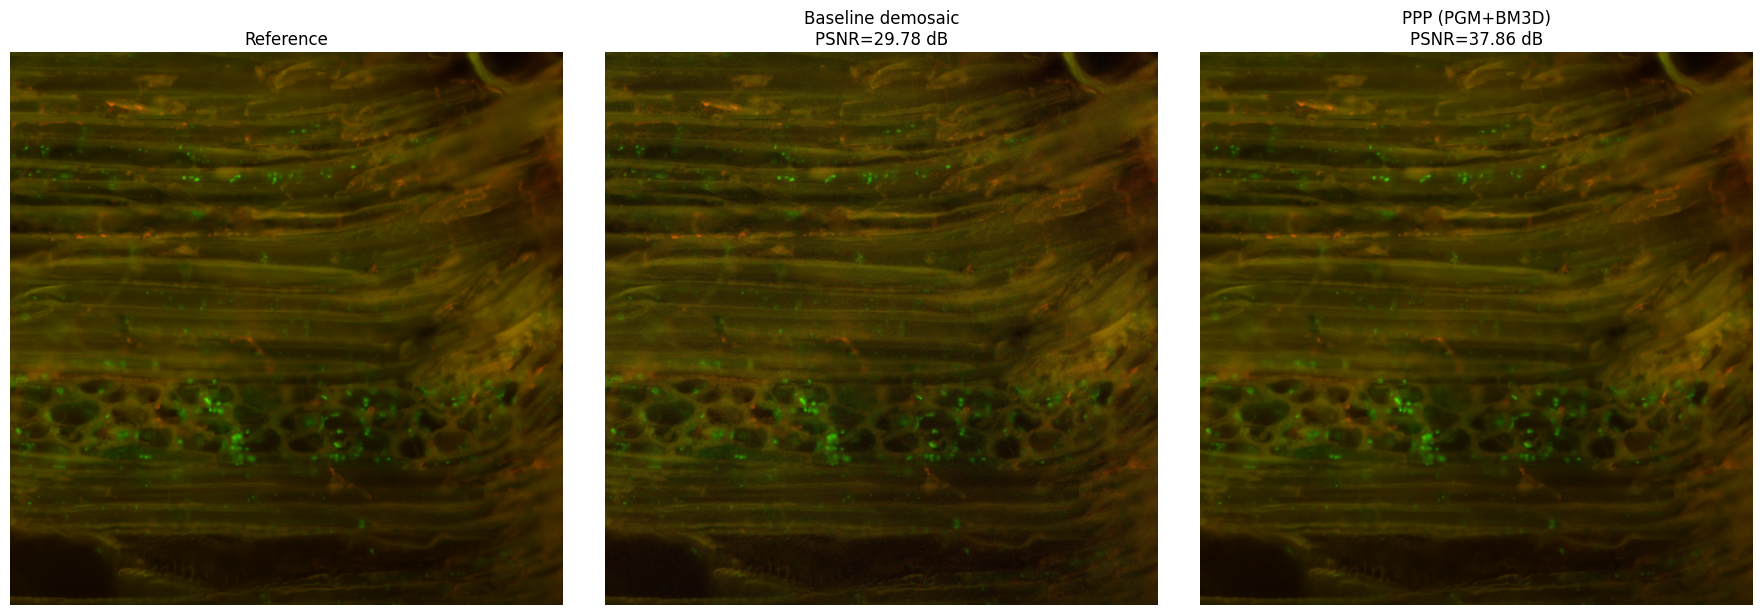

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(img)
ax[0].set_title("Reference")
ax[1].imshow(imgb)
ax[1].set_title(f"Baseline demosaic\nPSNR={psnr_imgb:.2f} dB")
ax[2].imshow(imgp)
ax[2].set_title(f"PPP (PGM+BM3D)\nPSNR={psnr_imgp:.2f} dB")
for a in ax: a.axis("off")

plt.tight_layout()
plt.show()